# Агентная SIR: β и время выявления

Сравним обнаружение на 3-й и 7-й день: по 30 прогонов на вариант.

## Рабочее окружение

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("experiments.jl"))

comprehensive_analysis (generic function with 2 methods)

## Параметрическое расширение сканирования

In [2]:
rows = DataFrame[]
for detection in (3, 7)
    result = beta_scan(
        "sir_scan_beta__param/detection_$(detection)";
        detection_time = detection,
    )
    result.grouped[!, :detection] =
        fill(detection, nrow(result.grouped))
    push!(rows, result.grouped)
end

## Сопоставление средних пиков

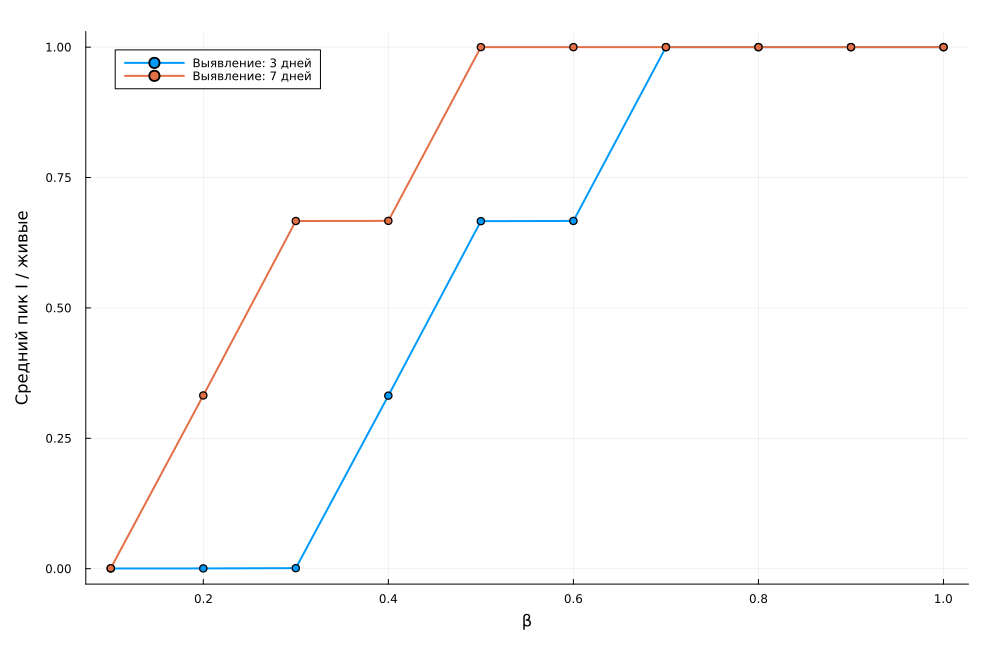

Row,beta,peak,final_inf,final_rec,deaths,death_fraction,detection
,Float64,Float64,Float64,Float64,Float64,Float64,Int64
1,0.1,0.000444444,0.0,0.000444444,0.0,0.0,3
2,0.2,0.000555556,0.0,0.000555556,0.0,0.0,3
3,0.3,0.00111111,0.0,0.00166667,0.0,0.0,3
4,0.4,0.331807,0.322968,0.0122546,46.0,0.0153333,3
5,0.5,0.666331,0.645472,0.0213061,165.0,0.055,3
6,0.6,0.666778,0.664451,0.00232648,204.667,0.0682222,3
7,0.7,1.0,0.99588,0.00411961,330.667,0.110222,3
8,0.8,1.0,0.992744,0.00725576,349.667,0.116556,3
9,0.9,1.0,0.962101,0.0378989,361.667,0.120556,3


In [3]:
summary = reduce(vcat, rows)
CSV.write(datafile("sir_scan_beta__param", "summary.csv"), summary)
figure = plot(; xlabel = "β", ylabel = "Средний пик I / живые")
for detection in (3, 7)
    subset = summary[summary.detection .== detection, :]
    plot!(
        figure,
        subset.beta,
        subset.peak;
        label = "Выявление: $(detection) дней",
        marker = :circle,
    )
end
savefig(figure, imagefile("07-plot.png"))
display(figure)
summary